In [466]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [467]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [468]:
df.shape

(891, 12)

In [469]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [470]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

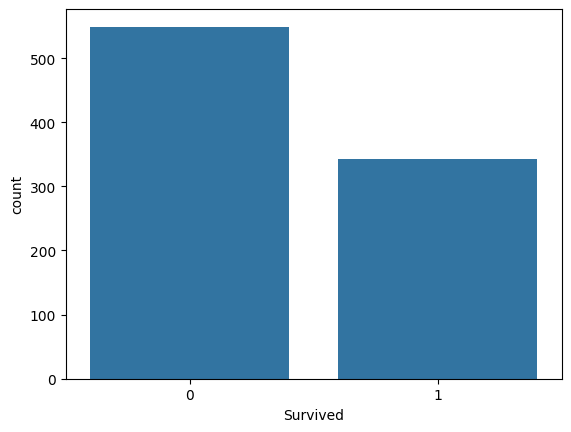

In [471]:
sns.countplot(x = 'Survived',data=df)
plt.show()

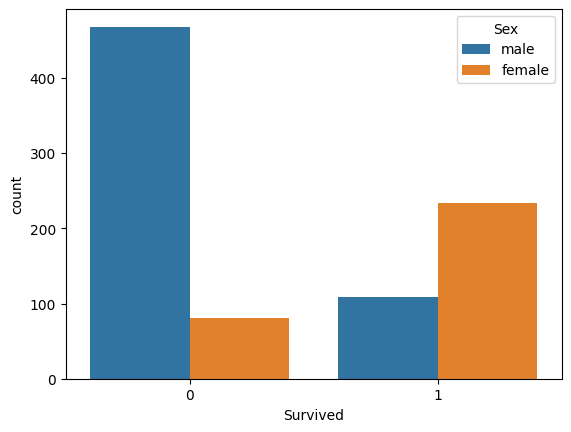

In [472]:
sns.countplot(x = 'Survived',hue='Sex',data=df)
plt.show()

In [473]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [474]:
df.drop(["Cabin", "PassengerId", "Name", "Ticket"], axis=1, inplace=True)

<Axes: >

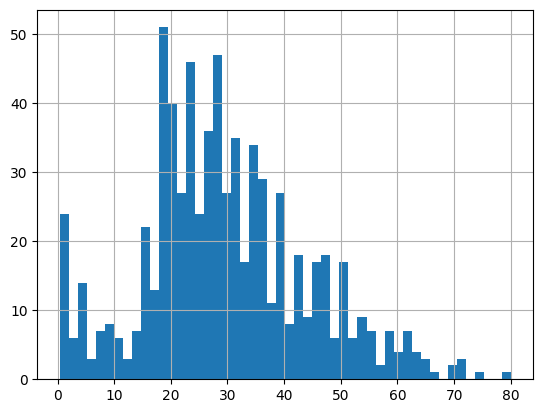

In [475]:
df["Age"].hist(bins=50)

<Axes: xlabel='Pclass', ylabel='Age'>

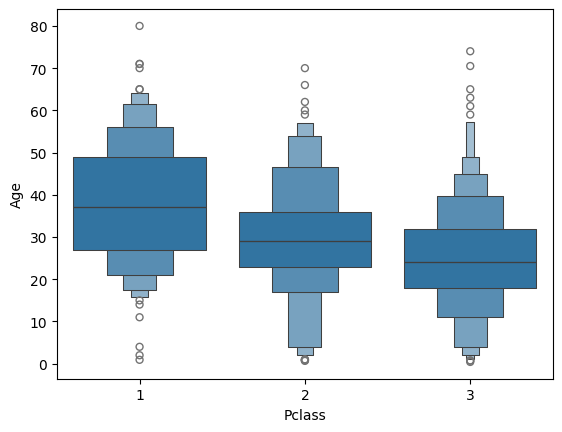

In [476]:
sns.boxenplot(x = "Pclass", y = "Age", data = df)

In [477]:
print(df[df["Pclass"]==3].describe())
print("_"*50)
df[df["Pclass"]==3]["Age"].mean()


         Survived  Pclass         Age       SibSp       Parch        Fare
count  491.000000   491.0  355.000000  491.000000  491.000000  491.000000
mean     0.242363     3.0   25.140620    0.615071    0.393075   13.675550
std      0.428949     0.0   12.495398    1.374883    0.888861   11.778142
min      0.000000     3.0    0.420000    0.000000    0.000000    0.000000
25%      0.000000     3.0   18.000000    0.000000    0.000000    7.750000
50%      0.000000     3.0   24.000000    0.000000    0.000000    8.050000
75%      0.000000     3.0   32.000000    1.000000    0.000000   15.500000
max      1.000000     3.0   74.000000    8.000000    6.000000   69.550000
__________________________________________________


np.float64(25.14061971830986)

In [478]:
# fill missing age with mean age of respective Pclass
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return df[df["Pclass"]==1]["Age"].mean() # this is the mean age of Pclass 1 which is 38.23
        elif Pclass == 2:
            return df[df["Pclass"]==2]["Age"].mean() # this is the mean age of Pclass 2 which is 29.88
        else:
            return df[df["Pclass"]==3]["Age"].mean() # this is the mean age of Pclass 3 which is 25.14
    else:
        return Age


df["Age"]= df[["Age","Pclass"]].apply(impute_age,axis=1)


C:\Users\e\AppData\Local\Temp\ipykernel_16896\3170581783.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\e\AppData\Local\Temp\ipykernel_16896\3170581783.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [479]:
df["Age"].isnull().sum()

np.int64(0)

In [480]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [481]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [482]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\e\AppData\Local\Temp\ipykernel_16896\122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


### **Handling Outliers**

---

<Axes: xlabel='Age'>

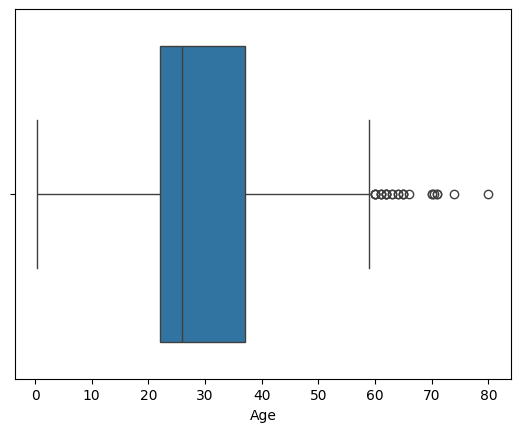

In [483]:
sns.boxplot(x = 'Age',data = df)

In [484]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR


#remove
df = df[(df['Age'] >=lower_bound )&(df['Age'] <= upper_bound )]

<Axes: xlabel='Age'>

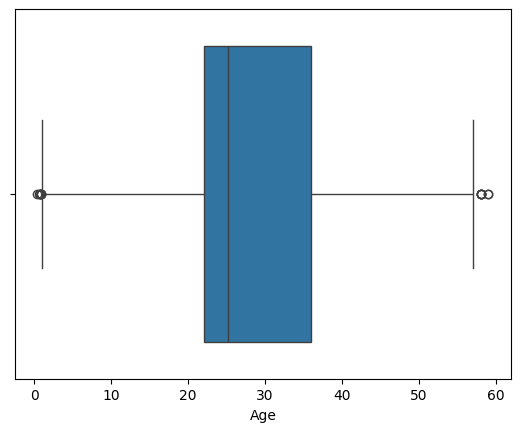

In [485]:
sns.boxplot(x = 'Age',data = df)

<Axes: xlabel='Fare'>

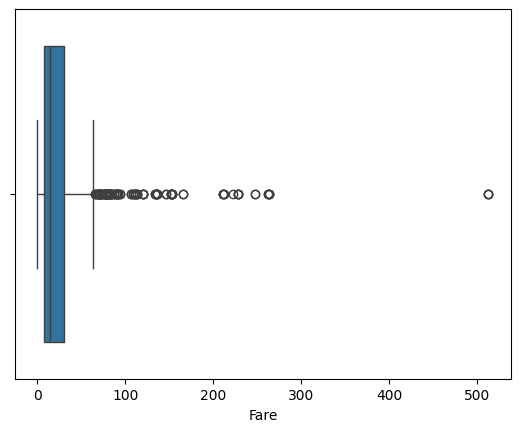

In [486]:
sns.boxplot(x = 'Fare',data = df)

In [487]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR


#remove
df = df[(df['Fare'] >=lower_bound )&(df['Fare'] <= upper_bound )]

<Axes: xlabel='Fare'>

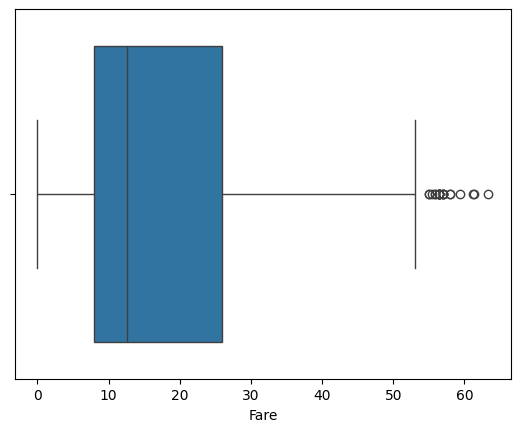

In [488]:
sns.boxplot(x = 'Fare',data = df)

In [489]:
df.shape

(753, 8)

In [490]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 753 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  753 non-null    int64  
 1   Pclass    753 non-null    int64  
 2   Sex       753 non-null    object 
 3   Age       753 non-null    float64
 4   SibSp     753 non-null    int64  
 5   Parch     753 non-null    int64  
 6   Fare      753 non-null    float64
 7   Embarked  753 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 52.9+ KB


In [491]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.00000,1,0,7.2500,S
2,1,3,female,26.00000,0,0,7.9250,S
3,1,1,female,35.00000,1,0,53.1000,S
4,0,3,male,35.00000,0,0,8.0500,S
5,0,3,male,25.14062,0,0,8.4583,Q


In [492]:
# now we have no missing values and no outliers in Age and Fare columns. 
# We can proceed with encoding the categorical variables and building the model.
new_df = pd.get_dummies(df, drop_first=True)

In [493]:
new_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.00000,1,0,7.2500,True,False,True
2,1,3,26.00000,0,0,7.9250,False,False,True
3,1,1,35.00000,1,0,53.1000,False,False,True
4,0,3,35.00000,0,0,8.0500,True,False,True
5,0,3,25.14062,0,0,8.4583,True,True,False


### **Building the model**

---

In [494]:
features = new_df.drop("Survived", axis=1)
target = new_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [495]:
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [496]:
y_pred= model.predict(X_test)

In [497]:
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1])

In [498]:
y_pred_pro= model.predict_proba(X_test)
y_pred_pro
# these are the probabilities of the classes. The first column is the probability of class 0 (not survived) 
# and the second column is the probability of class 1 (survived).
# for example, the first row [0.8, 0.2] means that the model predicts an 80% chance of
# not surviving and a 20% chance of surviving for that passenger 
# so the predicted class would be 0 (not survived) since it has the higher probability.

array([[0.87630667, 0.12369333],
       [0.86669965, 0.13330035],
       [0.47776433, 0.52223567],
       [0.89353237, 0.10646763],
       [0.3792862 , 0.6207138 ],
       [0.89046845, 0.10953155],
       [0.88949328, 0.11050672],
       [0.89046888, 0.10953112],
       [0.21626762, 0.78373238],
       [0.68885746, 0.31114254],
       [0.8966153 , 0.1033847 ],
       [0.92249596, 0.07750404],
       [0.84966482, 0.15033518],
       [0.4345267 , 0.5654733 ],
       [0.88915046, 0.11084954],
       [0.18883966, 0.81116034],
       [0.97908119, 0.02091881],
       [0.2704209 , 0.7295791 ],
       [0.54307964, 0.45692036],
       [0.97840106, 0.02159894],
       [0.86639898, 0.13360102],
       [0.86679444, 0.13320556],
       [0.86865187, 0.13134813],
       [0.37930708, 0.62069292],
       [0.92920541, 0.07079459],
       [0.26324219, 0.73675781],
       [0.84966482, 0.15033518],
       [0.8223826 , 0.1776174 ],
       [0.89353237, 0.10646763],
       [0.95144776, 0.04855224],
       [0.

In [499]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       107
           1       0.68      0.68      0.68        44

    accuracy                           0.81       151
   macro avg       0.78      0.78      0.78       151
weighted avg       0.81      0.81      0.81       151



In [500]:
from sklearn.metrics import accuracy_score

In [501]:
accuracy_score(y_test,y_pred)

0.8145695364238411

In [502]:
print(f'LogisticRegression Acc --> {accuracy_score(y_test,y_pred)*100} %')

LogisticRegression Acc --> 81.45695364238411 %
